In [22]:
import pandas as pd
import seaborn as sns
import numpy as np

In [23]:
df = pd.read_parquet('../data/master_select/index_meta.parquet')
df.columns

Index(['date', 'scode', 'is_candidate_tac', 'is_candidate_str',
       'log_market_cap', 'Future_High_Tac', 'Future_Low_Tac',
       'Future_Close_Tac', 'Future_High_Str', 'Future_Low_Str',
       'Future_Close_Str', 'target_ret_5', 'target_tac_vol_scaled_asym_return',
       'target_tac_vol_scaled_asym_return_clipped', 'target_tac_max_neg_path',
       'target_tac_risk', 'target_meta_survival_return_raw', 'target_ret_60',
       'target_str_sharpe_adj', 'target_str_triple_barrier', 'target_str_mdd',
       'target_str_vol_scaled_mdd', 'target_tac_rank', 'target_tac_gauss_rank',
       'target_tac_linear_residual', 'target_tac_sector_relative',
       'target_str_rank', 'target_str_gauss_rank', 'target_str_peer_alpha'],
      dtype='object')

### tac_risk修正

In [24]:
df['target_tac_max_neg_path'].describe()

count    6.645288e+06
mean    -3.429229e-02
std      4.153356e-02
min     -4.611316e+00
25%     -4.449887e-02
50%     -2.248999e-02
75%     -9.569451e-03
max      0.000000e+00
Name: target_tac_max_neg_path, dtype: float64

In [25]:
# positive downside severity
downside_severity = -df['target_tac_max_neg_path']
th_5 = -np.log(0.95)   # 約 +5.13%
th_7 = -np.log(0.93)   # 約 +7.26%
th_10 = -np.log(0.90)  # 約 +10.54%
cls = np.zeros(len(df), dtype="float32")
cls[downside_severity >= th_5] = 1
cls[downside_severity >= th_7] = 2
cls[downside_severity >= th_10] = 3

df["target_tac_risk_sev"] = downside_severity
df["target_tac_risk_5"] = (downside_severity >= th_5).astype("float32")
df["target_tac_risk_7"] = (downside_severity >= th_7).astype("float32")
df["target_tac_risk_10"] = (downside_severity >= th_10).astype("float32")
df["target_tac_risk_class"] = cls

In [26]:
df[['target_tac_risk_5','target_tac_risk_7','target_tac_risk_10']].describe()

,target_tac_risk_5,target_tac_risk_7,target_tac_risk_10
count,6.645288e+06,6.645288e+06,6.645288e+06
mean,2.040578e-01,1.120612e-01,5.050135e-02
std,4.059168e-01,3.048702e-01,2.152068e-01
min,0.000000e+00,0.000000e+00,0.000000e+00
25%,0.000000e+00,0.000000e+00,0.000000e+00
50%,0.000000e+00,0.000000e+00,0.000000e+00
75%,0.000000e+00,0.000000e+00,0.000000e+00
max,1.000000e+00,1.000000e+00,1.000000e+00


In [27]:
df['target_tac_risk_class'].value_counts()

target_tac_risk_class
0.0    5289265
1.0     611344
2.0     409083
3.0     335596
Name: count, dtype: int64

In [28]:
df.to_parquet('../data/master_select/index_meta.parquet')

In [4]:
df.groupby("date")[["target_ret_5", "target_tac_gauss_rank"]].corr()

target_ret_5  target_tac_gauss_rank
date                                                                 
2017-01-04 target_ret_5               1.000000               0.978456
           target_tac_gauss_rank      0.978456               1.000000
2017-01-05 target_ret_5               1.000000               0.955165
           target_tac_gauss_rank      0.955165               1.000000
2017-01-06 target_ret_5               1.000000               0.926351
...                                        ...                    ...
2026-04-28 target_tac_gauss_rank      0.952142               1.000000
2026-04-30 target_ret_5                    NaN                    NaN
           target_tac_gauss_rank           NaN                    NaN
2026-05-01 target_ret_5                    NaN                    NaN
           target_tac_gauss_rank           NaN                    NaN

[4530 rows x 2 columns]

In [7]:
df['target_tac_risk'].describe()

count    6.645288e+06
mean     1.073769e-03
std      6.707506e-02
min     -4.608418e+00
25%     -2.906700e-02
50%     -1.194804e-04
75%      2.868249e-02
max      7.438972e+00
Name: target_tac_risk, dtype: float64

<Axes: xlabel='target_tac_risk', ylabel='Count'>

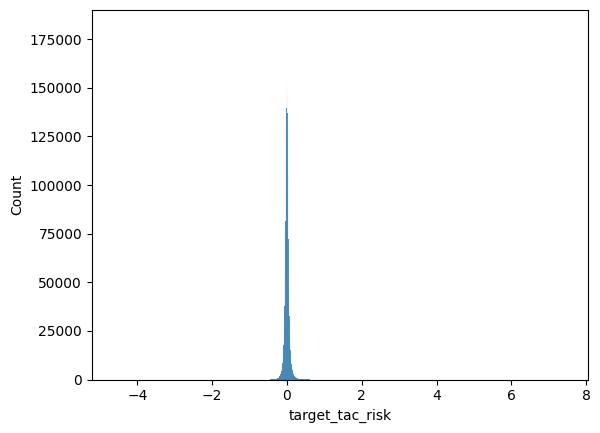

In [8]:
sns.histplot(df['target_tac_risk'])

In [5]:
df['target_tac_vol_scaled_asym_return_clipped'] = [2.0 if x>2.0 else x for x in df['target_tac_vol_scaled_asym_return_clipped']]

In [6]:
df['target_str_sharpe_adj'] = [3.0 if x>3.0 else x for x in df['target_str_sharpe_adj']]
df['target_str_sharpe_adj'] = [-3.0 if x<3.0 else x for x in df['target_str_sharpe_adj']]

In [6]:
df.to_parquet('../data/master_select/index_meta.parquet')